Saving dataset_1_sports_ticket_conjoint.xlsx to dataset_1_sports_ticket_conjoint (5).xlsx
Dataset Shape: (14880, 28)

Columns Available:
['respondent_id', 'profile_id', 'fan_segment', 'age', 'gender', 'income_band', 'city_distance_band', 'team_loyalty_score', 'price_sensitivity_index', 'merchandise_affinity_score', 'comfort_preference_score', 'travel_distance_km', 'prior_matches_last_season', 'seat_zone', 'opponent_tier', 'match_day', 'kickoff_time', 'merch_bundle', 'food_voucher', 'parking_included', 'digital_collectible', 'price_inr', 'rating_1_10', 'purchase_intent_binary', 'stated_wtp_inr', 'latent_utility_true_for_teaching', 'response_quality_flag', 'train_test_split']

Design Matrix Shape: (11195, 14)

CONJOINT ANALYSIS RESULTS
                                   OLS Regression Results                                   
Dep. Variable:     latent_utility_true_for_teaching   R-squared:                       0.294
Model:                                          OLS   Adj. R-squared: 

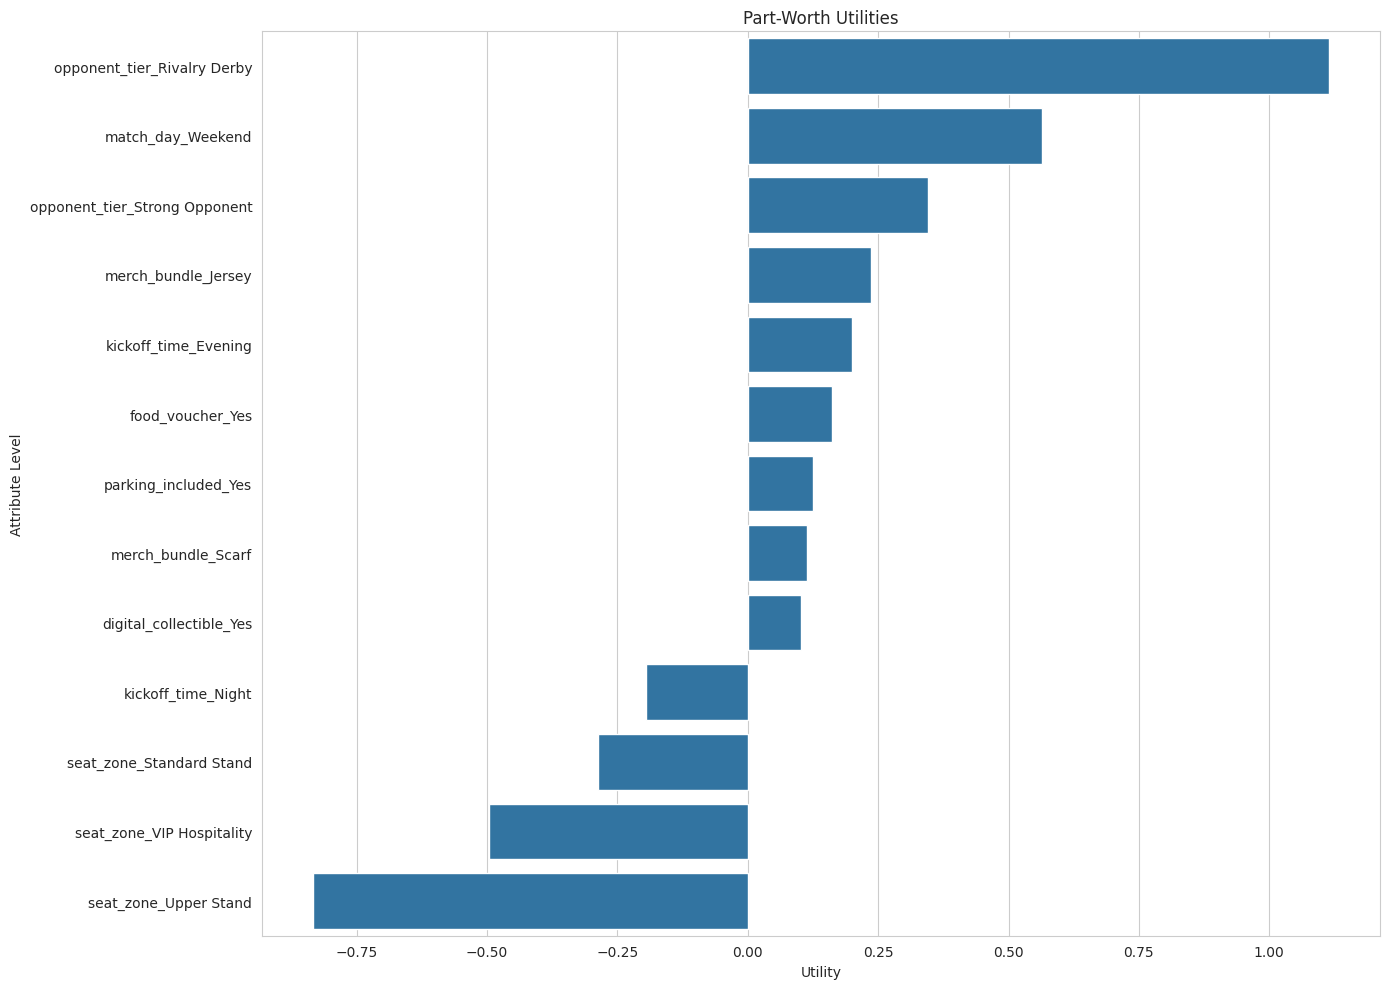


ATTRIBUTE IMPORTANCE
             Attribute     Range  Importance_%
1        opponent_tier  0.769956     41.917750
0            seat_zone  0.547355     29.798961
3         kickoff_time  0.395763     21.546043
4         merch_bundle  0.123752      6.737247
2            match_day  0.000000      0.000000
5         food_voucher  0.000000      0.000000
6     parking_included  0.000000      0.000000
7  digital_collectible  0.000000      0.000000


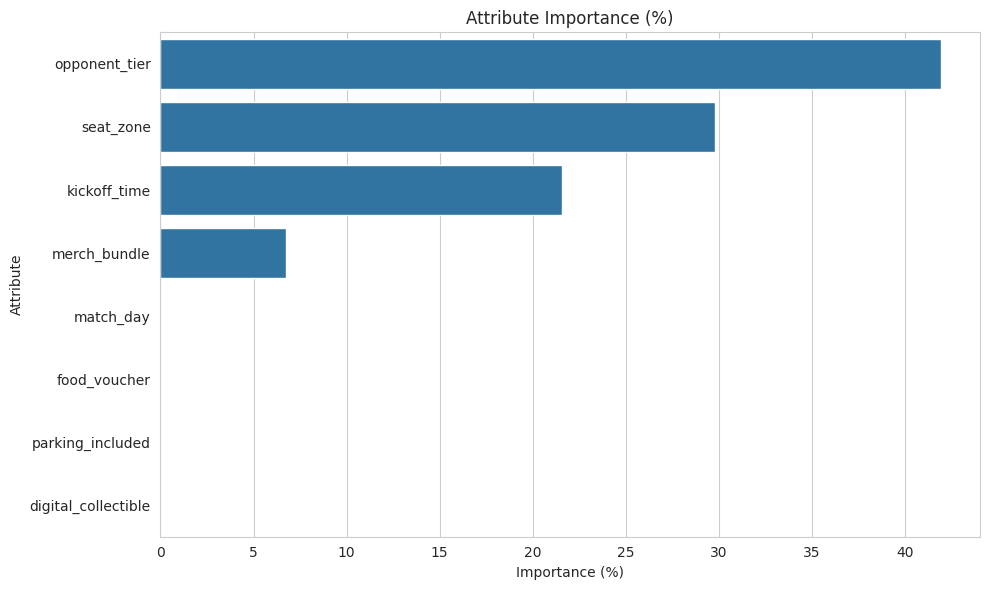

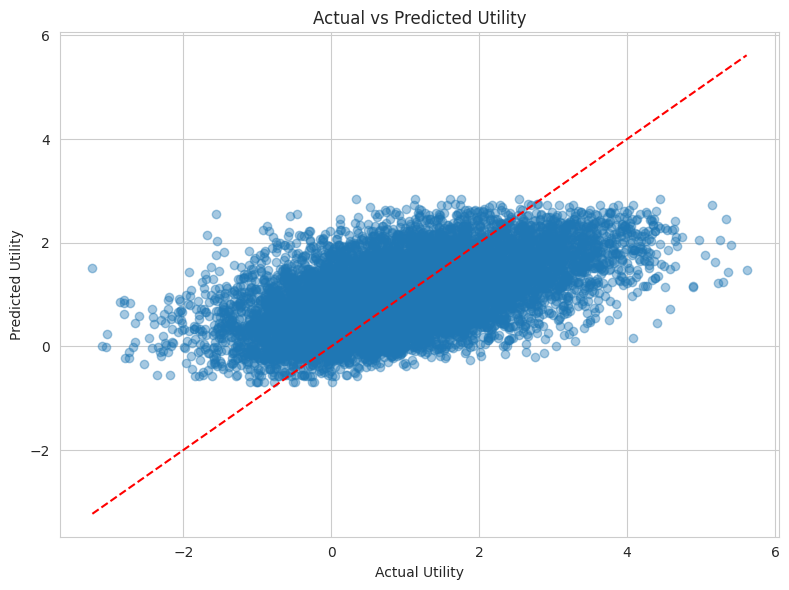


MODEL PERFORMANCE
R² = 0.2944
Adjusted R² = 0.2936

TOP 10 MOST PREFERRED TICKET PROFILES


,seat_zone,opponent_tier,match_day,kickoff_time,merch_bundle,food_voucher,parking_included,digital_collectible,Predicted_Utility
4624,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,Yes,2.850856
6618,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,Yes,2.850856
13559,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,Yes,2.850856
12598,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,Yes,2.850856
10195,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,Yes,2.850856
10417,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,Yes,2.850856
7672,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,No,2.749540
6677,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,No,2.749540
5771,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,No,2.749540
601,Premium Stand,Rivalry Derby,Weekend,Evening,Jersey,Yes,Yes,No,2.749540



Files Exported Successfully:
1. Part_Worth_Utilities.xlsx
2. Attribute_Importance.xlsx
3. Top_Profiles.xlsx


In [5]:
# =====================================================
# SPORTS TICKET CONJOINT ANALYSIS
# =====================================================

!pip install pandas numpy openpyxl statsmodels seaborn matplotlib -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# =====================================================
# UPLOAD EXCEL FILE
# =====================================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Dataset Shape:", df.shape)
print("\nColumns Available:")
print(df.columns.tolist())

# =====================================================
# CONJOINT ATTRIBUTES
# =====================================================

attributes = [
    'seat_zone',
    'opponent_tier',
    'match_day',
    'kickoff_time',
    'merch_bundle',
    'food_voucher',
    'parking_included',
    'digital_collectible'
]

# =====================================================
# TARGET VARIABLE
# =====================================================

target = "latent_utility_true_for_teaching"

# Alternative options:
# target = "rating_1_10"
# target = "purchase_intent_binary"

# =====================================================
# DATA PREPARATION
# =====================================================

conjoint_df = df[attributes + [target]].copy()

conjoint_df[target] = pd.to_numeric(
    conjoint_df[target],
    errors="coerce"
)

conjoint_df = conjoint_df.dropna()

# =====================================================
# CREATE DESIGN MATRIX
# =====================================================

X = pd.get_dummies(
    conjoint_df[attributes],
    drop_first=True,
    dtype=float
)

y = conjoint_df[target]

X = sm.add_constant(X)

print("\nDesign Matrix Shape:", X.shape)

# =====================================================
# FIT CONJOINT MODEL
# =====================================================

model = sm.OLS(y, X).fit()

print("\n====================================================")
print("CONJOINT ANALYSIS RESULTS")
print("====================================================")

print(model.summary())

# =====================================================
# PART-WORTH UTILITIES
# =====================================================

utilities = model.params.drop("const")

utility_df = pd.DataFrame({
    "Attribute_Level": utilities.index,
    "Part_Worth_Utility": utilities.values
})

utility_df = utility_df.sort_values(
    by="Part_Worth_Utility",
    ascending=False
)

print("\nTop Positive Utilities")
print(utility_df.head(15))

print("\nTop Negative Utilities")
print(utility_df.tail(15))

# =====================================================
# VISUALIZATION 1
# PART WORTH UTILITIES
# =====================================================

plt.figure(figsize=(14,10))

sns.barplot(
    data=utility_df,
    x="Part_Worth_Utility",
    y="Attribute_Level"
)

plt.title("Part-Worth Utilities")
plt.xlabel("Utility")
plt.ylabel("Attribute Level")
plt.tight_layout()
plt.show()

# =====================================================
# ATTRIBUTE IMPORTANCE
# =====================================================

importance = {}

for attr in attributes:

    cols = [
        col for col in utility_df["Attribute_Level"]
        if col.startswith(attr + "_")
    ]

    if len(cols) > 0:

        values = utility_df[
            utility_df["Attribute_Level"].isin(cols)
        ]["Part_Worth_Utility"]

        importance[attr] = values.max() - values.min()

importance_df = pd.DataFrame({
    "Attribute": importance.keys(),
    "Range": importance.values()
})

importance_df["Importance_%"] = (
    importance_df["Range"] /
    importance_df["Range"].sum()
) * 100

importance_df = importance_df.sort_values(
    by="Importance_%",
    ascending=False
)

print("\nATTRIBUTE IMPORTANCE")
print(importance_df)

# =====================================================
# VISUALIZATION 2
# ATTRIBUTE IMPORTANCE
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance_%",
    y="Attribute"
)

plt.title("Attribute Importance (%)")
plt.xlabel("Importance (%)")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

# =====================================================
# PREDICTIONS
# =====================================================

predictions = model.predict(X)

results_df = pd.DataFrame({
    "Actual": y,
    "Predicted": predictions
})

# =====================================================
# VISUALIZATION 3
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    results_df["Actual"],
    results_df["Predicted"],
    alpha=0.4
)

plt.plot(
    [results_df["Actual"].min(),
     results_df["Actual"].max()],
    [results_df["Actual"].min(),
     results_df["Actual"].max()],
    'r--'
)

plt.title("Actual vs Predicted Utility")
plt.xlabel("Actual Utility")
plt.ylabel("Predicted Utility")
plt.tight_layout()
plt.show()

# =====================================================
# MODEL PERFORMANCE
# =====================================================

print("\nMODEL PERFORMANCE")
print("R² =", round(model.rsquared,4))
print("Adjusted R² =", round(model.rsquared_adj,4))

# =====================================================
# TOP TICKET PROFILES
# =====================================================

full_X = pd.get_dummies(
    df[attributes],
    drop_first=True,
    dtype=float
)

full_X = full_X.reindex(
    columns=X.columns.drop("const"),
    fill_value=0
)

full_X = sm.add_constant(full_X)

df["Predicted_Utility"] = model.predict(full_X)

top_profiles = df.sort_values(
    by="Predicted_Utility",
    ascending=False
)

print("\nTOP 10 MOST PREFERRED TICKET PROFILES")

display(
    top_profiles[
        attributes +
        ["Predicted_Utility"]
    ].head(10)
)

# =====================================================
# EXPORT RESULTS
# =====================================================

utility_df.to_excel(
    "Part_Worth_Utilities.xlsx",
    index=False
)

importance_df.to_excel(
    "Attribute_Importance.xlsx",
    index=False
)

top_profiles.to_excel(
    "Top_Profiles.xlsx",
    index=False
)

print("\nFiles Exported Successfully:")
print("1. Part_Worth_Utilities.xlsx")
print("2. Attribute_Importance.xlsx")
print("3. Top_Profiles.xlsx")